In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from utils.model_fitting import *
from utils.plots import *
from utils.path import FigureWithData
from rl.models import Tonic_DA_model
import random
warnings.filterwarnings("ignore")
seed_value = 1234  # Or any integer you like
np.random.seed(seed_value)
random.seed(seed_value)
warnings.filterwarnings("ignore")

fig_dir = os.path.join('figures', 'figure_3')
data_fig_dir = os.path.join('data', 'source_data', 'figure_3')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)


### Figure 3a

This figure illustreates the mechanism by which increases or decreases in baseline dopamine modulates the degree to which bursts and pauses in dopamine causes changes in D1R and D2R occupancy.
- **Increases** in baseline dopamine makes dopamine pauses to cause greater decreases in D2R occupancy than the increases in D1R occupancy caused by dopamine bursts (blue). 
- **Decreases** in dopamine, makes dopamine bursts to cause smaller increases in D1R occupancy than the decreases in D2R occupancy caused by dopamine pauses (red).

Saved figure to figures/figure_3/figure_3a.pdf
Saved data and stats to data/figure_data/figure_3/figure_3a.txt


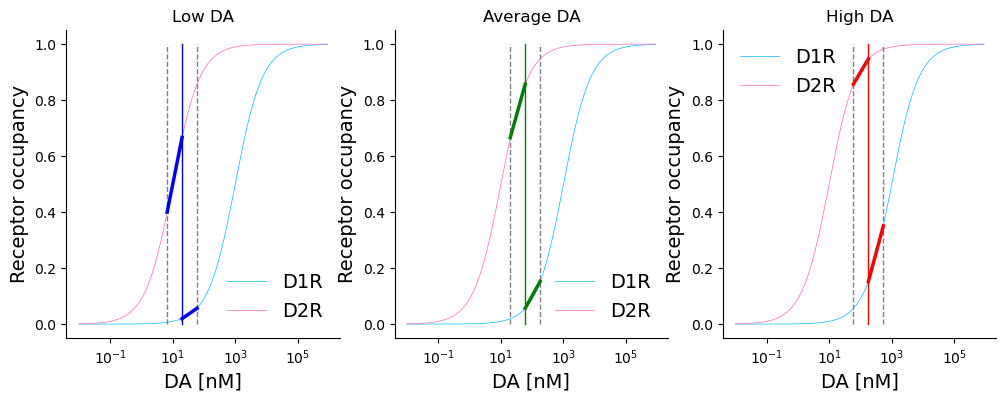

In [2]:
md = Tonic_DA_model()
DA = md.DA
ec50_1 = md.ec50_1
ec50_2 = md.ec50_2
delta_DA = md.delta_DA
slope_D1_log, slope_D2_log = md.compute_sensitivities(type_scale='log')
taus_log = md.compute_taus(type_scale='log')
slope_D1_lin, slope_D2_lin = md.compute_sensitivities(type_scale='lin')
taus_lin = md.compute_taus(type_scale='lin')
occ_D1, occ_D2, DA_occ =md.compute_dose_occupancy(DA_range = [-2,6])
colorD1 = 'deepskyblue'
colorD2 = 'hotpink'

DA_levels = np.asarray([60/3,60,60*3])
color_levels = ['blue','green','red']
tit_levels = ['Low DA','Average DA','High DA']

fig, ax = plt.subplots(1,3,figsize = (12,4))
[ia.semilogx(DA_occ,occ_D1,color=colorD1,linewidth=.5,label='D1R') for ia in ax]
[ia.semilogx(DA_occ,occ_D2,color=colorD2,linewidth=.5,label='D2R') for ia in ax]

[ia.plot([c, c],[0, 1],color = cl,linewidth=1) for (c,ia,cl) in zip(DA_levels,ax,color_levels)]
[ia.plot([c*delta_DA, c*delta_DA],[0, 1],color = 'grey',linestyle='--',linewidth=1) for (c,ia,cl) in zip(DA_levels,ax,color_levels)]
[ia.plot([c/delta_DA, c/delta_DA],[0, 1],color = 'grey',linestyle='--',linewidth=1) for (c,ia,cl) in zip(DA_levels,ax,color_levels)]

dDA_neg,dDA_pos = DA_levels/delta_DA, DA_levels*delta_DA
D2_levels, D1_levels = DA_levels/(DA_levels+ec50_2),DA_levels/(DA_levels+ec50_1)
dD2_levels, dD1_levels = dDA_neg/(dDA_neg+ec50_2),dDA_pos/(dDA_pos+ec50_1)

[ia.plot([c,dc],[r,dr] ,color=cl,linewidth=2.5)  for (ia,c,dc,r,dr,cl) in zip(ax,DA_levels,dDA_neg,D2_levels,dD2_levels,color_levels)]
[ia.plot([c,dc],[r,dr] ,color=cl,linewidth=2.5)  for (ia,c,dc,r,dr,cl) in zip(ax,DA_levels,dDA_pos,D1_levels,dD1_levels,color_levels)]

[plot_config(ia,'DA [nM]','Receptor occupancy',14,True) for ia in ax]
[title_(ia,tit) for (ia,tit) in zip(ax,tit_levels)]


# 1. Create the wrapper
fig_data_3a = FigureWithData(fig)

# 2. Add the occupancy curves
occupancy_data = np.column_stack((DA_occ, occ_D1, occ_D2))
fig_data_3a.add_data(
    "Occupancy curves",
    occupancy_data,
    ['DA_concentration_nM', 'Occupancy_D1R', 'Occupancy_D2R']
)

# 3. Add the discrete DA level points (arrows)
DA_levels_points = np.column_stack((
    DA_levels, D2_levels, dD2_levels, D1_levels, dD1_levels
))
fig_data_3a.add_data(
    "DA Levels and associated receptor occupancies",
    DA_levels_points,
    ['DA_level_nM', 'D2R_Occupancy', 'D2R_Occupancy_shifted', 'D1R_Occupancy', 'D1R_Occupancy_shifted']
)

# 4. Save everything (figure + txt)
fig_data_3a.save(
    base_filename='figure_3a',
    folder_data=data_fig_dir,
    folder_figures=fig_dir
)



### Figure 3c

Receptor sensitivity for D1R and D2R as a function of baseline dopamine. 

In Model 1 in the manuscript, we assume that the receptor sensitivity acts as a scaling factor on the PKA activity induced by burst and pauses.
That is:

$PKA_{D1} \propto \alpha_{D1} \cdot \delta \cdot \textbf{1}_{\delta>0}$ , where $ \alpha_{D1}$ is the receptor sensitivity for D1R

$PKA_{D2} \propto \alpha_{D2} \cdot \delta \cdot \textbf{1}_{\delta<0}$ , where $ \alpha_{D2}$ is the receptor sensitivity for D2R

The figure below plots the normalized receptor sensitivities

Saved figure to figures/figure_3/figure_3cd.pdf
Saved data and stats to data/figure_data/figure_3/figure_3cd.txt


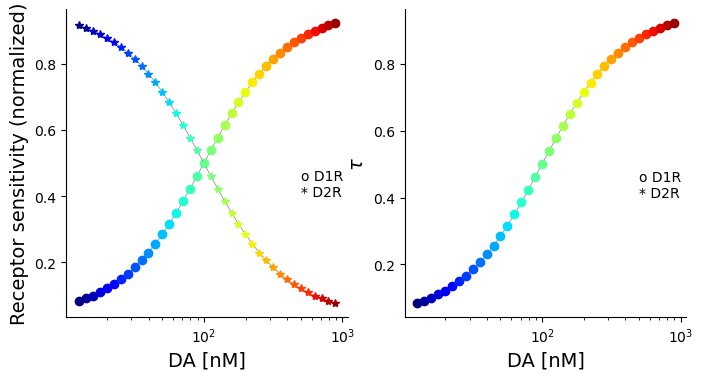

In [4]:
fig, ax = plt.subplots(1,2,figsize = (8,4))
ax[0].semilogx(DA,taus_log,color='grey',linewidth=.5)
_=[ax[0].semilogx(DA[ii],taus_log[ii],'o',color=cm.jet(ii/len(DA))) for ii in range(len(DA))]
ax[0].semilogx(DA,1-taus_log,color='grey',linewidth=.5)
_=[ax[0].semilogx(DA[ii],1-taus_log[ii],'*',color=cm.jet(ii/len(DA))) for ii in range(len(DA))]
plot_config(ax[0],'DA [nM]','Receptor sensitivity (normalized)',14,False)
ax[0].text(500,.45,'o D1R')
ax[0].text(500,.4,'* D2R')


ax[1].semilogx(DA,taus_log,color='grey',linewidth=.5)
_=[ax[1].semilogx(DA[ii],taus_log[ii],'o',color=cm.jet(ii/len(DA))) for ii in range(len(DA))]
plot_config(ax[1],'DA [nM]',r'$\tau$',14,False)
ax[1].text(500,.45,'o D1R')
ax[1].text(500,.4,'* D2R')

# 1. Create the wrapper
fig_data_3cd = FigureWithData(fig)

# 2. Add Panel 0: DA vs Tau_D1R and Tau_D2R
panel0_data = np.column_stack((DA, taus_log, 1 - taus_log))
panel0_headers = ['DA_concentration_nM', 'Tau_D1R', 'Tau_D2R']
fig_data_3cd.add_data(
    "Receptor sensitivities (Panel 0)",
    panel0_data,
    panel0_headers
)

# 3. Add Panel 1: DA vs Tau only
panel1_data = np.column_stack((DA, taus_log))
panel1_headers = ['DA_concentration_nM', 'Tau']
fig_data_3cd.add_data(
    "Tau values (Panel 1)",
    panel1_data,
    panel1_headers
)

# 4. Save everything (figure + data)
fig_data_3cd.save(
    base_filename='figure_3cd',    # or any name you want
    folder_data= data_fig_dir,
    folder_figures= fig_dir
)



Receptor sensitivity as the derivative of the dose-occupancy curves

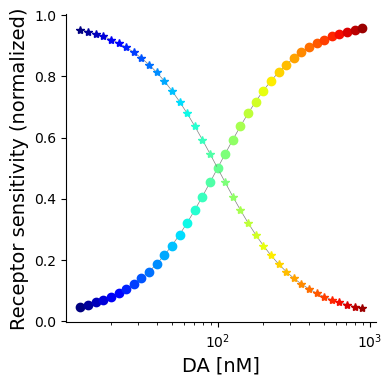

In [7]:
ec1 = md.ec50_1
ec2 = md.ec50_2
occ_D1 = DA/(DA+ec1)
occ_D2 = DA/(DA+ec2)

# Derivative: 
docc_d1 = occ_D1*(1-occ_D1)
docc_d2 = occ_D2*(1-occ_D2)
tau_occ = docc_d1/(docc_d1+docc_d2)

fig, ax = plt.subplots(figsize = (4,4))
ax.semilogx(DA,tau_occ,color='grey',linewidth=.5)
_=[ax.semilogx(DA[ii],tau_occ[ii],'o',color=cm.jet(ii/len(DA))) for ii in range(len(DA))]
ax.semilogx(DA,1-tau_occ,color='grey',linewidth=.5)
_=[ax.semilogx(DA[ii],1-tau_occ[ii],'*',color=cm.jet(ii/len(DA))) for ii in range(len(DA))]
plot_config(ax,'DA [nM]','Receptor sensitivity (normalized)',14,False)

### Closed form solutions for Value prediction

Below we compute the closed form solution for the value predictors for a Bernoulli distribution of rewards for Model 1 
Closed form solution is defined by: 

$$
V = \frac{\frac{\tau}{1-\tau}\cdot \frac{p}{1-p} \cdot r}{\frac{\tau}{1-\tau}\cdot \frac{p}{1-p} +1 +\frac{\beta}{(1-\tau)\cdot(1-p)}}
$$

where:
- $\tau$: asymmetric scaling factor (given by receptor sensitivity in Model 1)
- $p$: probability of reward in the Bernoulli distribution
- $r$: reward magnitude
- $\beta$: decay parameter in the update equation in Model 1

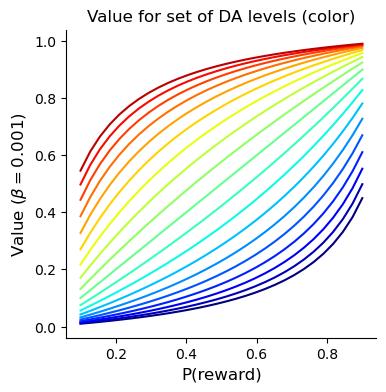

In [8]:

pv = np.linspace(0.1,0.9,30)
vs = np.asarray([md.compute_closed_form_bernoulli(p = p,r=1) for p in pv])
fig, ax = plt.subplots(figsize = (4,4))
_ = [ax.plot(pv,vs[:,ii],color=cm.jet(ii/vs.shape[1])) for  ii in np.arange(0,vs.shape[1],step=2)]
plot_config(ax,'P(reward)',r'Value ($\beta = $' + str(md.beta)+  ')',12,False)
title_(ax,'Value for set of DA levels (color)')